In [8]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling.models as models
import prism.modeling.fitting as fitting
from prism.modeling.fitting import tie
import prism.modeling.display # importing the display module enables the model display features

plt.rcParams['axes.xmargin'] = 0

In [9]:
filename = 'data/agnspec.txt'

# (Optional) Set the source coordinates and redshift
dec, ra = -25.12345, 13.12345
redshift = 0.0622

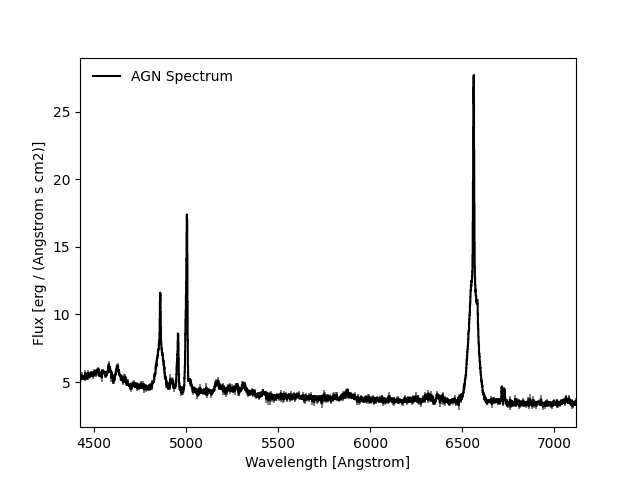

In [10]:
spec = Spectrum.from_txt(filename=filename,
                         ra=ra,
                         dec=dec,
                         z=redshift,
                         wave_unit=u.AA,
                         unit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
                         name='AGN Spectrum')

# # (Example) Mask a region
# wmask = (spec.wave <= 5800) | (spec.wave >= 5980)
# spec.crop(wmask=wmask)

# # (Example) Crop a portion of the spectrum
# wbounds = (4800., 7500.) # Å
# spec.crop(wbounds=wbounds)

# Apply Galactic extinction correction
spec.deredden()

# (Optional) Apply redshift correction to rest frame
spec.zcorrect()

spec.plot_spectrum() 

In [11]:
# (Optional) Copy locally the CSV file containing the line list, and set up the local line database.
models.setup_local_lines(wmin=np.min(spec.wave), wmax=np.max(spec.wave), overwrite=True)

# # If you want to blindly proceed with the default line list without inspecting it, you can use models.set_wavelength_range()
# # This will just filter the lines to those that fall within the wavelength range of interest.
# models.set_wavelength_range(wmin=np.min(spec.wave), wmax=np.max(spec.wave))

# NOTE: If you decide to work in the observed frame, you should remember to set the line database to the rest frame, i.e. models.set_wavelength_range(wmin=np.min(spec.wave)/(1+redshift), wmax=np.max(spec.wave)/(1+redshift))

Wavelength range set to: [4424.778761061947, 7117.303709282621]


In [12]:
# Line Models support instumental broadening. This can be set to either a constant value (in km/s) or a 2D array with wavelength and FWHM values (in km/s).
# The latter is useful when the instrumental resolution varies significantly across the wavelength range of interest.
# For the sake of simplicity we will use a constant value here, but I leave a snippet below to show how to set up a wavelength-dependent instrumental broadening based on the MUSE instrumental response.

instfwhm = 0. # km/s


# # Set wavelength-dependent instrumental broadening based on the MUSE instrumental response
# from astropy.constants import c
# c_kms = c.to('km/s').value

# # Instrumental Response of MUSE from the MUSE User Manual
# resp_lambda = np.array([4650.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0, 7500.0, 8000.0, 8500.0, 9000.0, 9350.0])
# resp_R = np.array([1609, 1750, 1978, 2227, 2484, 2737, 2975, 3183, 3350, 3465, 3506])

# wave_rest = resp_lambda * (1.0 + redshift) # Null the zcorrection for instrumental effects. Not needed if you are working in the observed frame.
# fwhm_km_s = c_kms / resp_R

# instfwhm = np.array([wave_rest, fwhm_km_s]).T

In [13]:
# Setup the model

# Continuum
bknpower = models.BrokenPowerlaw(
    name='bknpower',
    x_ref=5450,
    amplitude=np.median(spec.flux),
    index1=-2.0,
    index2=0.0,
    bounds={
        'x_ref': (5100, 5710),
        'amplitude': (1.5, 5.0),
        'index1': (-3.0, 0.0),
        'index2': (-1.0, 1.5),
    }
)

# Broad Line Region (BLR)
blr = models.agn.blr(
    name='blr',
    amplitude=10,
    offset=-360,
    fwhm=3727,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 1000),
        'offset': (-1000, 1000),
        'fwhm': (500, 8000),
    },
)

# Narrow Line Region (NLR)
nlr = models.agn.nlr(
    name='nlr',
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)

# Let's add Hydrogen and Helium lines tied to the NLR component. By default they are kept separate.
hhe_nlr = models.GaussianLines.from_csv(
    name='hhe_nlr',
    csv_files=['hydrogen.csv', 'helium.csv'],
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)
# Link the kinematics of the Hydrogen and Helium lines to those of the NLR component.
hhe_nlr.offset.tied = tie("nlr", lambda m: m.offset)
hhe_nlr.fwhm.tied = tie("nlr", lambda m: m.fwhm)

# OIII outflow
oiii_out = models.GaussianLines.from_csv(
    name='oiii',
    csv_files=['oiii.csv'],
    amplitude=1,
    offset=-560,
    fwhm=850,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-1000, 750),
        'fwhm': (50, 1500),
    }
)

# FeII Model
fe = models.agn.fe(
    name='fe',
    offset=0,
    fwhm=1200,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-3000, 3000),
        'fwhm': (800, 3000),
    }
)


# Combine all components
model = bknpower + blr + nlr + hhe_nlr + oiii_out + fe

In [14]:
from prism.modeling import instrument

# Create the wavelength grid in the observer frame (not redshift corrected)
# Standard grid for agnspec.txt: 4700 to 7560 Angstrom
wave_obs = np.arange(4700, 7561.25, 1.25)

# Define the FWHM gradient from 100 to 120 km/s
fwhm_kms = np.linspace(100, 120, len(wave_obs))

# Convert FWHM from km/s to Angstrom: FWHM_ang = (v / c) * lambda
from astropy.constants import c
c_kms = c.to('km/s').value
fwhm_ang = (fwhm_kms / c_kms) * wave_obs

# Calculate Gaussian sigma values
sigmas = fwhm_ang / (2 * np.sqrt(2 * np.log(2)))

# Build the sparse response matrix
# Using the internal helper from InstrumentResponse
matrix = instrument.InstrumentResponse._build_sparse_gaussian_matrix(wave_obs, sigmas)

# Create the InstrumentResponse instance (temporary, not saved to disk)
custom_ir = instrument.InstrumentResponse(wave_obs, matrix)

# Apply to the model using SpectralResponse (passing the instance directly)
# This keeps it temporary for this session and does not write to the archive.
lsf = instrument.SpectralResponse(instrument=custom_ir, wave=spec.wave, z=spec.z, name='lsf')
model = model | lsf # Apply the response


In [15]:
model

<CompoundModel((bknpower + blr + nlr + hhe_nlr + oiii + fe) | lsf; amplitude_0=3.92125, x_ref_0=5450, index1_0=-2, index2_0=0, ...)>

In [16]:
# from astropy.modeling.fitting import TRFLSQFitter
# fitter = TRFLSQFitter()
# fitter.max_evaluations = 5000

fitter = fitting.SherpaLM() # Very robust altrnative for bounded problems to astropy defaults! Ensure to have Sherpa installed in your environment.

fitted_model = fitter(model=model, x=spec.wave, y=spec.flux, yerr=spec.err, inplace=True)

In [17]:
# Compute chi-squared
residuals = spec.flux - fitted_model(spec.wave)
chi_squared = np.sum((residuals / spec.err) ** 2)

print(f"Chi-squared: {chi_squared:.2f}")

Chi-squared: 2779.06


In [18]:
# Manually print the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'std') and param.std is not None:
        print(f"  {name:16s}: {param.value:8.4f} ± {param.std:2g}")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     :   3.9130 ± 0.00139194
  x_ref_0         : 5485.8881 ± 2.63582
  index1_0        :  -1.2527 ± 0.00319194
  index2_0        :   0.6742 ± 0.00340986
  amp_hb4861_1    :   3.1986 ± 0.0019384
  amp_ha6562_1    :   9.2669 ± 0.0103629
  amp_hei4471_1   :   0.2039 ± 0.00967042
  amp_heii4685_1  :   0.0014 ± 0.00546084
  amp_hei5877_1   :   0.3472 ± 0.000713922
  amp_hei6678_1   :   0.1439 ± 0.00154734
  amp_hei7065_1   :   0.1960 ± 0.00181833
  offset_1        : -131.4274 ± 0.45684
  fwhm_1          : 2502.1534 ± 0.791141
  redshift_1      :   0.0000
  amp_oiii5007_2  :   8.6569 ± 0.0596402
  amp_nii6583_2   :   1.7208 ± 0.0241178
  amp_oi6300_2    :   0.1177 ± 0.0188743
  amp_oi6363_2    :   0.4367 ± 0.0127301
  amp_sii6716_2   :   1.1531 ± 0.0132195
  amp_sii6730_2   :   0.9370 ± 0.00123539
  offset_2        : -58.9687 ± 0.244282
  fwhm_2          : 273.2881 ± 0.592206
  redshift_2      :   0.0000
  amp_hb4861_3    :   4.5424 ± 0.0300497
  amp_ha6562_3    :  15.8961 ± 0.0

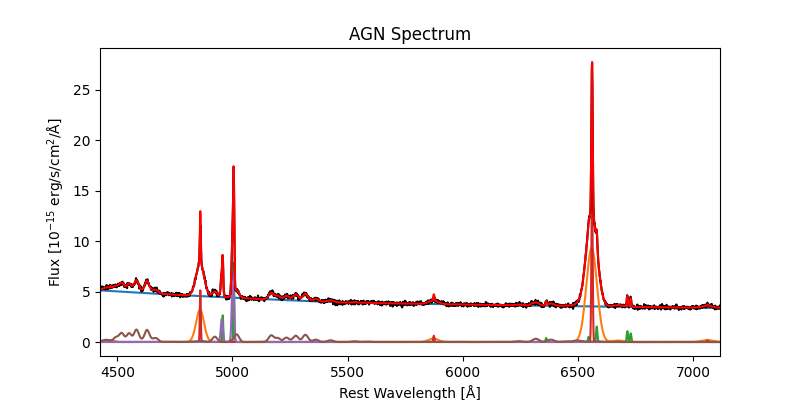

In [37]:
plt.figure(figsize=(8, 4))

comps = models.get_components(fitted_model, additive=True)
for name in comps.names:
    plt.plot(spec.wave, comps[name](spec.wave), label=name)

plt.plot(spec.wave, spec.flux, label='Data', color='black')
plt.plot(spec.wave, fitted_model(spec.wave), label='Model', color='red')
plt.xlabel('Rest Wavelength [Å]')
plt.ylabel('Flux [10$^{-15}$ erg/s/cm$^2$/Å]')

# plt.ylim(bottom=0.1)
# plt.yscale('log')

plt.title(spec.name)

plt.show()

In [20]:
# Our line models support the .flux attribute, which gives us the integrated flux of the line.
nlr.flux

,value,std,lolim,uplim
[OIII]5007,55.933262,0.403956,NaN,NaN
[NII]6583,14.634998,0.207550,NaN,NaN
[OI]6300,0.719220,0.115377,NaN,NaN
[OI]6363,2.695891,0.078811,NaN,NaN
[SII]6716,7.513800,0.087664,NaN,NaN
[SII]6730,6.118878,0.015521,NaN,NaN


In [21]:
# If the fitter uses covariance in the fitting process, by default we will add the .std attribute to the parameters of the model.
# In some cases you might want to estimate the uncertainties on the best-fit parameters using more robust methods, such as bootstrapping.
# We implement it in an easy way in prism, and it can be used with any of the available fitters.
# We perturb the data around their uncertainties, and we refit the model to each perturbed dataset.
# This will give us a distribution of best-fit parameters from which we can estimate the uncertainties.
# We supprt parallelized fitting! For simple models and small datasets, you can set nproc=1 to avoid the overhead of parallelization.
# For more complex models and larger datasets, you can increase nproc to speed up the process.

from prism.modeling.fitting.uncertainty import bootstrap

from astropy.modeling.fitting import TRFLSQFitter
fitter = TRFLSQFitter()
fitter.max_evaluations = 5000

# fitter = fitting.ScipyTRF()

# fitter = fitting.SherpaLM()

samples = bootstrap(model=fitted_model, 
                    fitter=fitter,
                    x=spec.wave, y=spec.flux, yerr=spec.err,
                    n_samples=200, seed=11,
                    nproc=4,
                    noise_dist='uniform'
                    )

Fitting spectra:   0%|          | 0/200 [00:00<?, ?it/s]

In [22]:
# Print the all the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    if hasattr(param, 'lolim') and param.lolim is not None:
        print(f"  {name:16s}: [{param.lolim:8.4f}, {param.uplim:8.4f}]")
    else:
        print(f"  {name:16s}: {param.value:8.4f}")

  amplitude_0     : [  3.9115,   3.9141]
  x_ref_0         : [5485.0417, 5487.7121]
  index1_0        : [ -1.2530,  -1.2480]
  index2_0        : [  0.6687,   0.6754]
  amp_hb4861_1    : [  3.1984,   3.2015]
  amp_ha6562_1    : [  9.2669,   9.3403]
  amp_hei4471_1   : [  0.1751,   0.2039]
  amp_heii4685_1  : [     nan,   0.0148]
  amp_hei5877_1   : [  0.3469,   0.3487]
  amp_hei6678_1   : [  0.1415,   0.1441]
  amp_hei7065_1   : [  0.1935,   0.1996]
  offset_1        : [-131.4274, -129.5060]
  fwhm_1          : [2499.1144, 2502.1534]
  redshift_1      :   0.0000
  amp_oiii5007_2  : [  8.4844,   8.6817]
  amp_nii6583_2   : [  1.6552,   1.7223]
  amp_oi6300_2    : [  0.0780,   0.1221]
  amp_oi6363_2    : [  0.4108,   0.4527]
  amp_sii6716_2   : [  1.1531,   1.2026]
  amp_sii6730_2   : [  0.9370,   0.9577]
  offset_2        : [-61.0294, -58.9687]
  fwhm_2          : [266.1915, 273.2881]
  redshift_2      :   0.0000
  amp_hb4861_3    : [  4.5424,   5.7965]
  amp_ha6562_3    : [ 15.8961,  17

In [23]:
# Print the paramters with fluxes
components = models.get_components(fitted_model)

for i, name in enumerate(components.names):
    comp = components[i]

    if isinstance(comp, models.LineGroupBase):
        for line in comp.lines[comp.lines['weight'] == 1]['name']: # Drop lines with weight!=1. Repeated entries otherwise.
            flux = comp.flux.loc[line, 'value']
            flux_limits = comp.flux.loc[line, ['lolim', 'uplim']]
            if flux_limits.notnull().any():
                print(f"  {name:12s} flux_{line:15s} [{flux_limits['lolim']:8.4f}, {flux_limits['uplim']:8.4f}]")
            else:
                print(f"  {name:12s} flux_{line:15s} {flux:8.4f} ± {comp.flux.loc[line, 'std']:2g}")

    for parname in comp.param_names:
        param = getattr(comp, parname)
        if hasattr(param, 'lolim') and param.lolim is not None:
            print(f"  {name:12s} {parname:20s} [{param.lolim:8.4f}, {param.uplim:8.4f}]")
        else:
            print(f"  {name:12s} {parname:20s} {param.value:8.4f}")


  bknpower|lsf amplitude_0          [  3.9115,   3.9141]
  bknpower|lsf x_ref_0              [5485.0417, 5487.7121]
  bknpower|lsf index1_0             [ -1.2530,  -1.2480]
  bknpower|lsf index2_0             [  0.6687,   0.6754]
  blr|lsf      amp_hb4861_0         [  3.1984,   3.2015]
  blr|lsf      amp_ha6562_0         [  9.2669,   9.3403]
  blr|lsf      amp_hei4471_0        [  0.1751,   0.2039]
  blr|lsf      amp_heii4685_0       [     nan,   0.0148]
  blr|lsf      amp_hei5877_0        [  0.3469,   0.3487]
  blr|lsf      amp_hei6678_0        [  0.1415,   0.1441]
  blr|lsf      amp_hei7065_0        [  0.1935,   0.1996]
  blr|lsf      offset_0             [-131.4274, -129.5060]
  blr|lsf      fwhm_0               [2499.1144, 2502.1534]
  blr|lsf      redshift_0             0.0000
  nlr|lsf      amp_oiii5007_0       [  8.4844,   8.6817]
  nlr|lsf      amp_nii6583_0        [  1.6552,   1.7223]
  nlr|lsf      amp_oi6300_0         [  0.0780,   0.1221]
  nlr|lsf      amp_oi6363_0         [

In [24]:
from prism.utils import fmt

# Print the all the best-fit parameters
for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    value = param.median if hasattr(param, 'median') else param.value
    lolim = getattr(param, 'lolim', None)
    uplim = getattr(param, 'uplim', None)
    print(f"  {name:16s}: {fmt(value=value, lo=lolim, hi=uplim)}")


  amplitude_0     : 3.913 [-0.002, +0.001]
  x_ref_0         : 5485.9 [-0.8, +1.8]
  index1_0        : -1.252 [-0.001, +0.004]
  index2_0        : 0.674 [-0.005, +0.002]
  amp_hb4861_1    : 3.1993 [-0.0010, +0.0021]
  amp_ha6562_1    : 9.32 [-0.05, +0.02]
  amp_hei4471_1   : 0.19 [-0.02, +0.01]
  amp_heii4685_1  : < 0.01
  amp_hei5877_1   : 0.3475 [-0.0005, +0.0012]
  amp_hei6678_1   : 0.1432 [-0.0016, +0.0009]
  amp_hei7065_1   : 0.196 ± 0.003
  offset_1        : -130.2 [-1.2, +0.7]
  fwhm_1          : 2500 [-1, +2]
  redshift_1      : 0
  amp_oiii5007_2  : 8.61 [-0.13, +0.07]
  amp_nii6583_2   : 1.70 [-0.04, +0.02]
  amp_oi6300_2    : 0.11 [-0.03, +0.01]
  amp_oi6363_2    : 0.44 [-0.03, +0.02]
  amp_sii6716_2   : 1.18 [-0.02, +0.03]
  amp_sii6730_2   : 0.950 [-0.013, +0.008]
  offset_2        : -60 ± 1
  fwhm_2          : 270 ± 4
  redshift_2      : 0
  amp_hb4861_3    : 5.6 [-1.0, +0.2]
  amp_ha6562_3    : 16.4 [-0.5, +0.6]
  amp_hei4471_3   : 0.18 [-0.02, +0.03]
  amp_heii4685_3  :

In [25]:
from prism.utils import tex

for name in fitted_model.param_names:
    param = getattr(fitted_model, name)
    value = param.median if hasattr(param, 'median') else param.value
    lolim = getattr(param, 'lolim', None)
    uplim = getattr(param, 'uplim', None)
    print(f"  {name:16s}: {tex(value=value, lo=lolim, hi=uplim, use_sci=True, maxexp=4)}")

  amplitude_0     : 3.913_{-0.002}^{+0.001}
  x_ref_0         : 5485.9_{-0.8}^{+1.8}
  index1_0        : -1.252_{-0.001}^{+0.004}
  index2_0        : 0.674_{-0.005}^{+0.002}
  amp_hb4861_1    : 3.1993_{-0.0010}^{+0.0021}
  amp_ha6562_1    : 9.32_{-0.05}^{+0.02}
  amp_hei4471_1   : 0.19_{-0.02}^{+0.01}
  amp_heii4685_1  : < 0.01
  amp_hei5877_1   : 0.3475_{-0.0005}^{+0.0012}
  amp_hei6678_1   : 0.1432_{-0.0016}^{+0.0009}
  amp_hei7065_1   : 0.196 \pm 0.003
  offset_1        : -130.2_{-1.2}^{+0.7}
  fwhm_1          : 2500_{-1}^{+2}
  redshift_1      : 0
  amp_oiii5007_2  : 8.61_{-0.13}^{+0.07}
  amp_nii6583_2   : 1.70_{-0.04}^{+0.02}
  amp_oi6300_2    : 0.11_{-0.03}^{+0.01}
  amp_oi6363_2    : 0.44_{-0.03}^{+0.02}
  amp_sii6716_2   : 1.18_{-0.02}^{+0.03}
  amp_sii6730_2   : 0.950_{-0.013}^{+0.008}
  offset_2        : -60 \pm 1
  fwhm_2          : 270 \pm 4
  redshift_2      : 0
  amp_hb4861_3    : 5.6_{-1.0}^{+0.2}
  amp_ha6562_3    : 16.4_{-0.5}^{+0.6}
  amp_hei4471_3   : 0.18_{-0.02}^{

In [26]:
# Our line models support the .flux attribute, which gives us the integrated flux of the line.
nlr.flux

,value,std,lolim,uplim
[OIII]5007,54.935254,0.936980,53.395461,56.093190
[NII]6583,14.264487,0.342842,13.710924,14.647378
[OI]6300,0.659919,0.148792,0.464183,0.746368
[OI]6363,2.661206,0.142088,2.470171,2.795032
[SII]6716,7.572448,0.172902,7.318661,7.836060
[SII]6730,6.122749,0.084648,5.959966,6.253904


In [27]:
fe.flux

,value,std,lolim,uplim
a4G,7.232381e+01,0.242739,71.940020,72.564268
a4H,1.365736e+00,0.122556,1.199404,1.502029
a6S,5.395138e+01,0.472129,53.311107,54.354886
b2H,3.647400e-04,0.124678,NaN,0.149647
b4D,2.780105e-02,0.045197,NaN,0.066757
b4F,8.166071e+01,0.400481,81.324022,82.308666
b4P,1.791263e+01,0.295319,17.749997,18.266393
z4D,3.101725e+01,0.235197,30.805822,31.331632
z4F,2.846569e+00,0.091585,2.763049,2.958502
y4G,1.256647e+01,0.369627,12.227125,13.018247


In [28]:
# Access specific entry (pandas.DataFrame)
fe.flux.loc['a4G', 'value']

np.float64(72.32381479513889)

In [29]:
nlr.lines

,name,pos,weight
0,[OIII]5007,4958.911,0.333333
1,[OIII]5007,5006.843,1.000000
2,[NII]6583,6548.050,0.333333
3,[NII]6583,6583.450,1.000000
4,[OI]6300,6300.304,1.000000
5,[OI]6363,6363.776,1.000000
6,[SII]6716,6716.440,1.000000
7,[SII]6730,6730.810,1.000000


In [30]:
nlr.eqw() # Compute the Equivalent Width of the line. By default it uses the local continuum, but you can also specify a different continuum model if you want.

# Access the computed EW
nlr.ew

,value,std,lolim,uplim
[OIII]5007,1.256355e+32,2.142850e+30,1.221140e+32,1.282837e+32
[NII]6583,1.368135e+10,3.288268e+08,1.315042e+10,1.404859e+10
[OI]6300,6.920343e+00,1.560333e+00,4.867723e+00,7.826904e+00
[OI]6363,6.990062e+00,3.732165e-01,6.488281e+00,7.341576e+00
[SII]6716,7.377433e+00,1.684491e-01,7.130181e+00,7.634256e+00
[SII]6730,7.393217e+00,1.022119e-01,7.196658e+00,7.551587e+00


In [31]:
fitted_model.show()

In [32]:
# The user can also save the fitted model and its parameters to a file, and load them later for inspection or further analysis, without the need to re-run the fitting process from scratch.
from prism.modeling.io import load_params, load_model

outfile = "results/agnmodel.fits"
fitted_model.save(outfile, overwrite=True)

lp = load_params(outfile)
lm = load_model(outfile)
print("amp_hb:", lp["amp_hb4861_1"])
print("model class:", type(lm).__name__)

/Users/pierpaolo/SciSoft/git/prism-spec/.venv/lib/python3.11/site-packages/yaml/representer.py:27: UserWarning: Linear-operator pipe model has no reconstruction recipe. The model will be saved without the response operator. Re-apply the response after loading.
  node = self.represent_data(data)


amp_hb: 3.1993472566173002
model class: CompoundModel


/Users/pierpaolo/SciSoft/git/prism-spec/.venv/lib/python3.11/site-packages/yaml/constructor.py:100: UserWarning: Model was saved with a direct response matrix that cannot be reconstructed from a recipe.  Re-apply the response manually.
  data = constructor(self, node)
